In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d
from quantem.core.visualization import show_2d

from importlib.metadata import version # Temporary fix for version check
print(f"quantEM version: {version("quantem")}")

from quantem.diffractive_imaging import (
    PtychographyDatasetRaster,
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
)

GPU_ID = 0
config.set_device(GPU_ID)
print(f"Using GPU {config.get('device')}")

quantEM version: 0.1.8
Using GPU cuda:0


In [3]:
filepath = Path("/home/wdekleijne/git-repos/willem-playground/data/gold_20mrad_10kev_1e+07-dose_Nyquist_plane_3_layer_fcc_inf_plane_60-80_512x512.zip")
# filepath = Path("/home/wdekleijne/git-repos/willem-playground/data/gold_20mrad_C10_C21_Nyquist.zip")

dset: Dataset4dstem = em.io.load(filepath)
print(dset)

quantem Dataset named '4d dataset'
  shape: (24, 24, 512, 512)
  dtype: int64
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [0.83333333 0.83333333 0.86507794 0.86507794]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'


In [4]:
PROBE_ENERGY = 10e3 # eV
PROBE_SEMIANGLE = 20 # mrad
PROBE_DEFOCUS = 0 # A 

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/576 [00:00<?, ?probe position/s]

regular intensities:


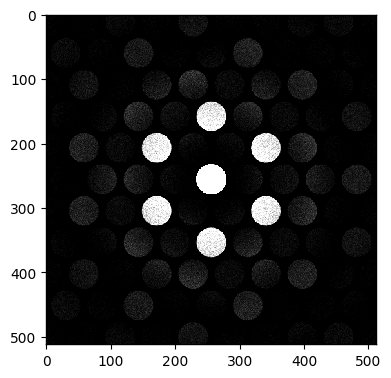

average: 4.117412567138672
max: 107.0
average: 3088.428955078125
max: 3351.1318359375
masked intensities:


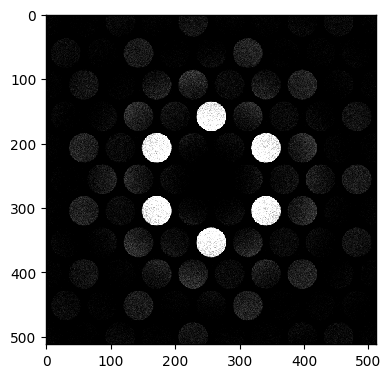

corr.shape: torch.Size([576, 512, 512])
correlation map:


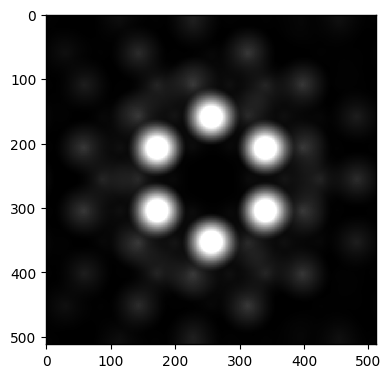

disk positions for test image 250, with measured positions:


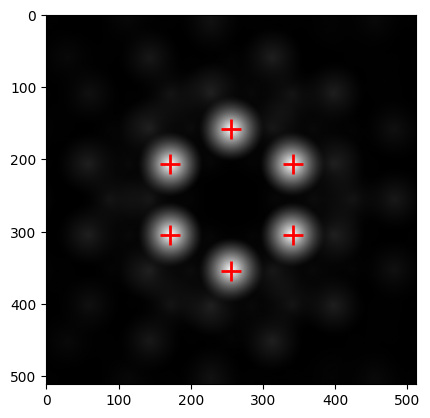

density plot of all disk positions across all images:


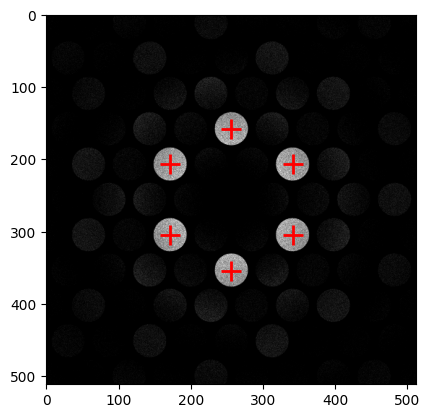

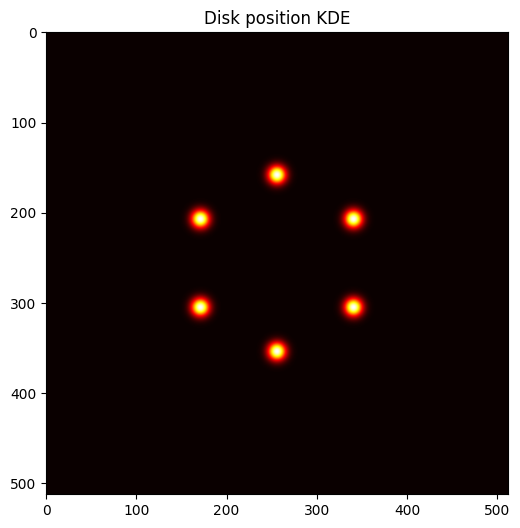

In [5]:
import matplotlib.pyplot as plt
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
probe_params = {
    "energy": PROBE_ENERGY,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}
pdset.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    determine_disks=True,
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="pure_phase",
    num_slices=3,
    slice_thicknesses=2,
)

probe_params = {
    "energy": PROBE_ENERGY,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}
probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()

In [6]:
# tensorboard logging is optional 
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix = Ptychography.from_models( 
    dset=pdset,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
)

ptycho_pix.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

  0%|          | 0/300 [00:00<?, ?it/s]

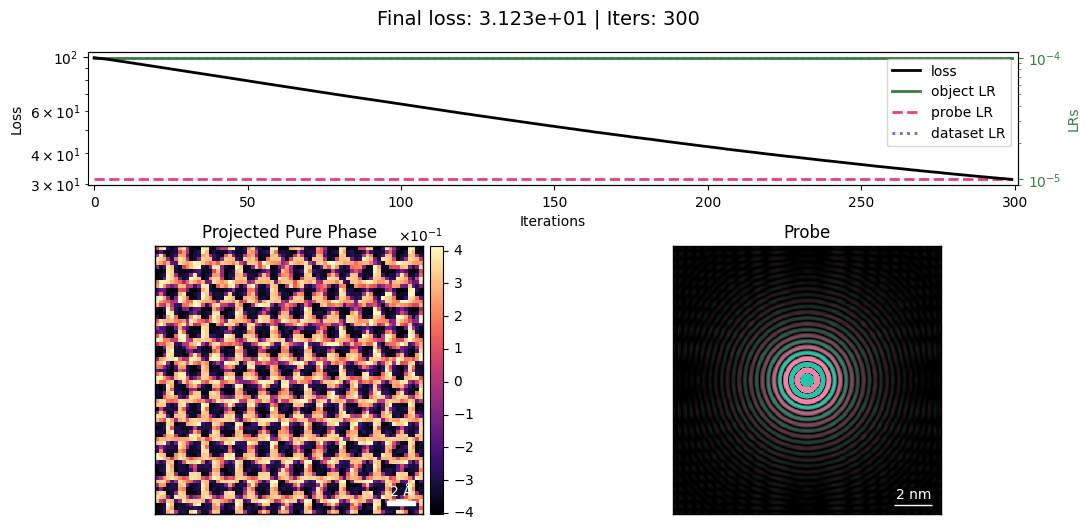

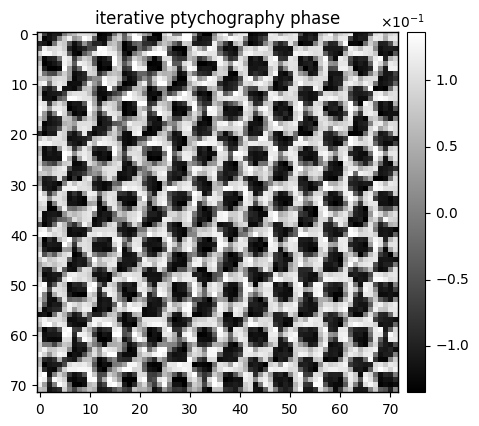

In [10]:
opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 1e-4, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-5, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 1e-4,
        }
}

scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,

    }
}

constraints = {
    "object": {
        "identical_slices": True, # default for this is False 
    },
    "dataset": {
        "center_scan_positions": True,
    }
}
ptycho_pix_reconstruct = ptycho_pix.reconstruct(
    num_iters=300,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints, 
    batch_size=128,
    device="cuda:0",
    store_snapshots_every=1,
    autograd=False,
    autograd_random=False,
)

ptycho_pix_reconstruct.visualize()

em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(ptycho_pix_reconstruct.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
);


In [9]:
ptycho_pix_reconstruct.show_iters(
    show_probe=False,
    every_nth=6,
    cmap='magma',
)